In [1]:
from gensim.models import Word2Vec

model = Word2Vec.load("/home/muhammad-farrukh-javed/fyp/ai-ml/models/skill2vec.model")

from skill_utils import suggest_similar_skills




In [2]:
# Example: Similarity between 'python' and 'django'
similarity = model.wv.similarity('python', 'django')
print(f"Similarity between 'python' and 'django': {similarity:.4f}")

Similarity between 'python' and 'django': 0.8766


In [3]:
# Example after suggestion
similar_skills = model.wv.most_similar('machine learning', topn=5)
for skill, score in similar_skills:
    print(f"{skill}: {score:.4f}")


artificial intelligence: 0.9593
natural language processing: 0.9511
data scientist: 0.9484
text mining: 0.9434
logistic regression: 0.9429


In [4]:
result=suggest_similar_skills("data_scientist", model)
print(f"Analogy result: {result}")


'data_scientist' found in vocabulary.
Analogy result: ['data scientist']


In [5]:
from sklearn.cluster import KMeans
import numpy as np

# Extract vectors for all skills
skill_vectors = model.wv.vectors
skill_names = model.wv.index_to_key

# Perform K-Means clustering
kmeans = KMeans(n_clusters=10, random_state=0)
kmeans.fit(skill_vectors)

# Display top skills in each cluster
for i in range(10):
    cluster_indices = np.where(kmeans.labels_ == i)[0]
    cluster_skills = [skill_names[index] for index in cluster_indices[:5]]
    print(f"Cluster {i+1}: {', '.join(cluster_skills)}")


Cluster 1: , steam sterilizer, emc documentum, formulation experience candidate, technical competency design information system security firewall
Cluster 2: communication skill, operation, project management, problem, tool
Cluster 3: security, biotechnology, physics, businessrequirement, pharmacy
Cluster 4: bpo, customer service, voice process, technical support, fresher
Cluster 5: pr mr, advertising corporate communication mr, advertising public relation mr, advertising medium relation mr, technical head
Cluster 6: javascript, html, sql, jquery, css
Cluster 7: cloud, infrastructure, firewall, dns, network
Cluster 8: finance, accounting, banking, taxation, ms office
Cluster 9: production, autocad, education, research, technical
Cluster 10: sale, business development, marketing, recruitment, corporate sale


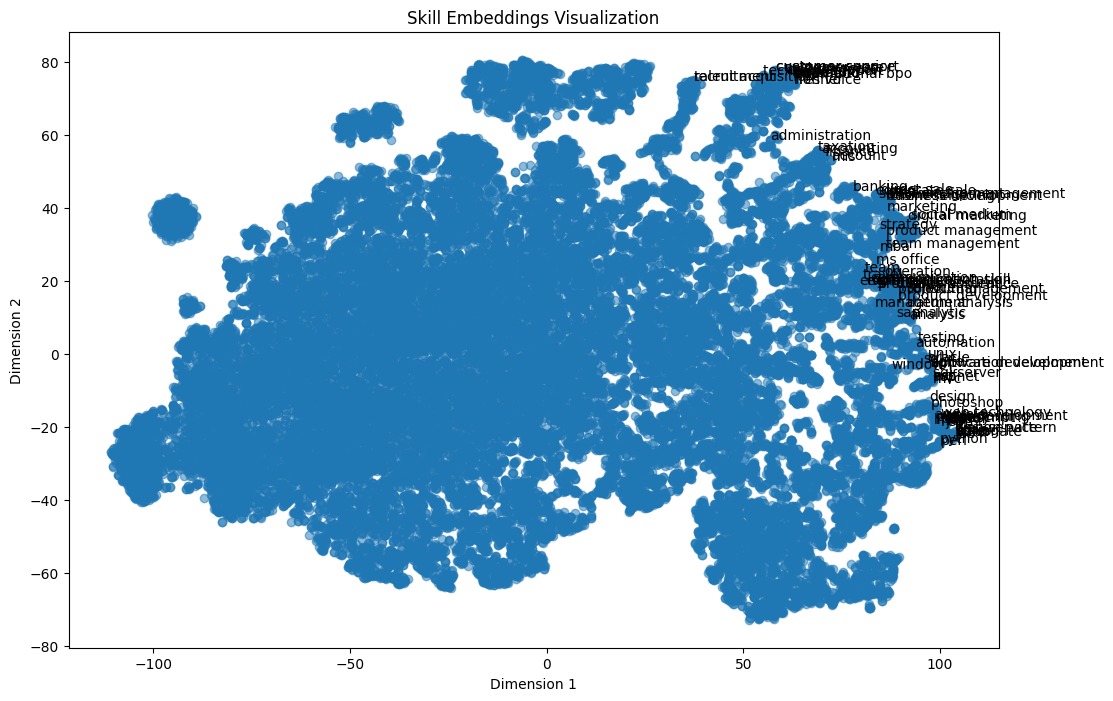

In [10]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reduce dimensions
tsne = TSNE(n_components=2, random_state=0)
reduced_vectors = tsne.fit_transform(skill_vectors)

# Plot the embeddings
plt.figure(figsize=(12, 8))
plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1], alpha=0.5)
for i, skill in enumerate(skill_names[:100]):  # Annotate first 100 skills
    plt.annotate(skill, (reduced_vectors[i, 0], reduced_vectors[i, 1]))
plt.title("Skill Embeddings Visualization")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()
